In [2]:
#data import
import numpy as np
import matplotlib.pyplot as plt

data = np.load("./dataset.npz")
print(data.files)
print(data['arr_0'].shape) 
print(data['arr_1'].shape) 
print(np.unique(data['arr_0'][0]))
print(data['arr_1'][0])   

['arr_0', 'arr_1']
(38015, 52, 52)
(38015, 8)
[0 1 2]
[1 0 1 0 0 0 1 0]


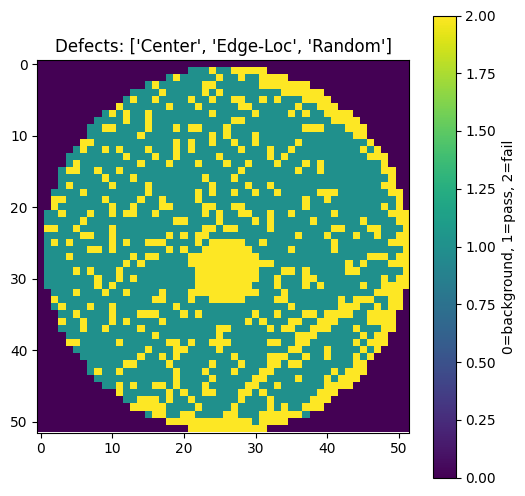

In [3]:
defect_names = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 
                'Loc', 'Near-full', 'Random', 'Scratch']

plt.figure(figsize=(6, 6))
plt.imshow(data['arr_0'][0])
plt.title(f"Defects: {[defect_names[i] for i, v in enumerate(data['arr_1'][0]) if v == 1]}")
plt.colorbar(label='0=background, 1=pass, 2=fail')
plt.show()

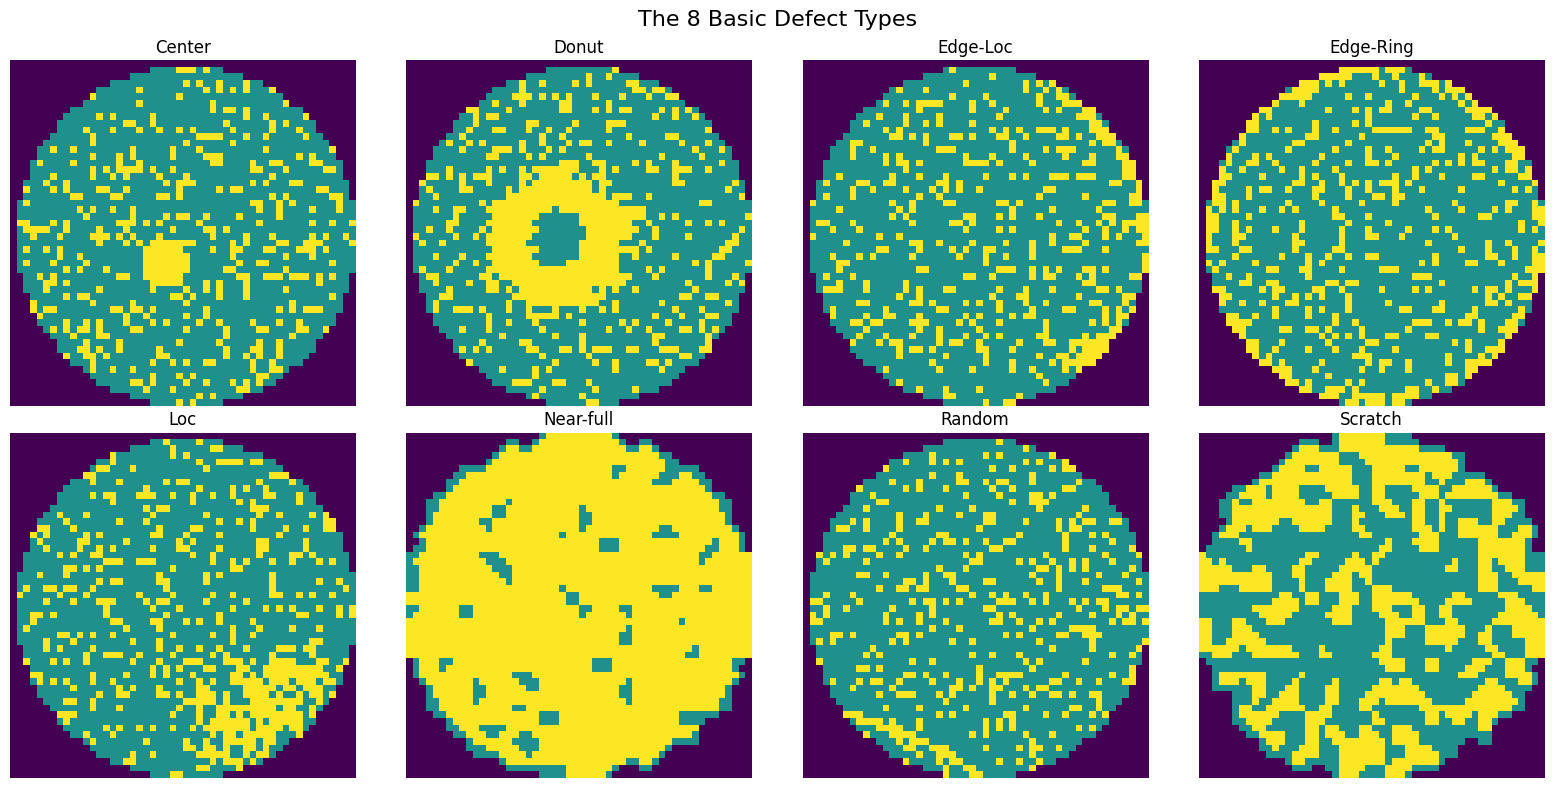

In [4]:
fig, axes = plt.subplots(2,4, figsize=(16,8))

for idx, (ax, name) in enumerate(zip(axes.flat, defect_names)):
    # Find a wafer that has ONLY this defect type
    mask = (data['arr_1'][:, idx] == 1) & (data['arr_1'].sum(axis=1) == 1)
    example_idx = np.where(mask)[0][0]
    
    ax.imshow(data['arr_0'][example_idx], cmap='viridis')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle('The 8 Basic Defect Types', fontsize=16)
plt.tight_layout()
plt.show()

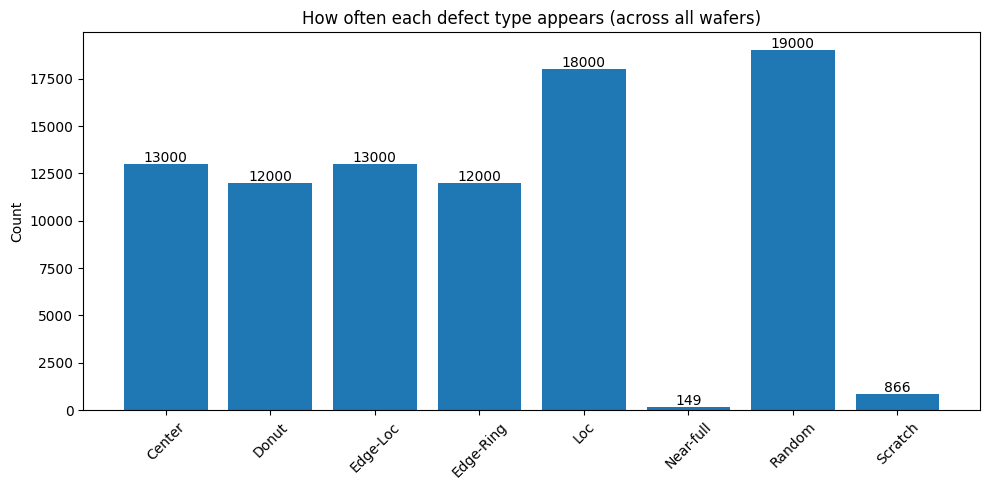

In [5]:
label_counts = data['arr_1'].sum(axis=0).astype(int)

plt.figure(figsize=(10, 5))
plt.bar(defect_names, label_counts)
plt.title('How often each defect type appears (across all wafers)')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, count in enumerate(label_counts):
    plt.text(i, count + 100, str(count), ha='center')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
#datasplit
X_train, X_test, y_train, y_test = train_test_split(
    data['arr_0'], data['arr_1'], 
    test_size=0.2, 
    random_state=1337
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (30412, 52, 52), Test: (7603, 52, 52)


In [ ]:
class WaferDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        #grab data via images
        image = self.images[idx].astype(np.float32)
        
        # Normalize: scale from [0, 1, 2] to [0, 0.5, 1.0]
        image = image / 2.0
        
        # Resize 52x52 -> 224x224 
        image = torch.tensor(image).unsqueeze(0).unsqueeze(0)
        image = F.interpolate(image, size=(224, 224), mode='bilinear', align_corners=False)
        
        # Repeat single channel to RGB
        image = image.squeeze(0).repeat(3, 1, 1)  # (3, 224, 224)    
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return image, label

#Dataset creation
train_dataset = WaferDataset(X_train, y_train)
test_dataset = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Single batch verification
images, labels = next(iter(train_loader))
print(f"Batch images: {images.shape}")   
print(f"Batch labels: {labels.shape}")   
print(f"Pixel range: {images.min():.2f} to {images.max():.2f}")

Batch images: torch.Size([64, 3, 224, 224])
Batch labels: torch.Size([64, 8])
Pixel range: 0.00 to 1.00


In [ ]:
import torch.nn as nn
import torchvision.models as models

# Calculate pos_weight for class imbalance
# This tells the loss function how much to penalize missing each class
label_counts = y_train.sum(axis=0)
total_samples = len(y_train)
pos_weight = (total_samples - label_counts) / (label_counts + 1e-6)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

print("Pos weights per class:")
for name, weight in zip(defect_names, pos_weight):
    print(f"  {name}: {weight:.1f}")

# Build model
print("downloading pretrained weights")
model = models.resnet18(pretrained=True)
print("done")
# Freeze early layers — they already know edges and textures
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for our 8-class multi-label task
# Only this layer will train initially
model.fc = nn.Linear(model.fc.in_features, 8)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
pos_weight = pos_weight.to(device)

print(f"\nUsing device: {device}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")